# Phase 1: Image Exploration
In this notebook, we verify our image loading pipeline and explore how a computer 'sees' an image.

In [1]:
import sys
import os
import matplotlib.pyplot as plt

# Add the src directory to the Python path so we can import our modules
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

from data.image_loader import load_image, tensor_to_image

## 1. Load Images
Please make sure your images are saved in `data/content_images/mcgregor.jpg` and `data/style_images/icarus.jpg`.

In [2]:
# Define paths (Update these if you named your images differently)
content_path = '../data/content_images/mcgregor.jpg'
style_path = '../data/style_images/icarus.jpg'

# Load images
content_tensor = load_image(content_path, max_size=400)
style_tensor = load_image(style_path, max_size=400)

if content_tensor is not None and style_tensor is not None:
    print(f"Content Tensor Shape: {content_tensor.shape}")
    print(f"Style Tensor Shape: {style_tensor.shape}")
else:
    print("Could not load images. Please check the file paths.")

Content Tensor Shape: torch.Size([1, 3, 500, 400])
Style Tensor Shape: torch.Size([1, 3, 664, 400])


Notice the shape: `[1, 3, Height, Width]`.
- `1` = Batch size (we process one image at a time)
- `3` = Color channels (Red, Green, Blue)
- `Height` and `Width` = Pixel dimensions

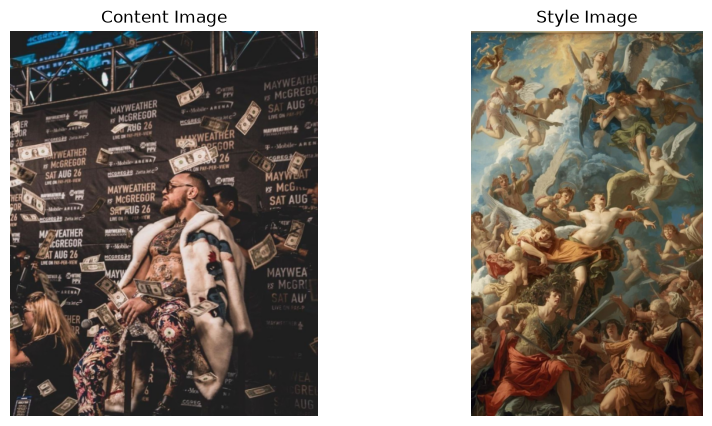

In [3]:
def imshow(tensor, title=None):
    """Utility function to display a tensor as an image using Matplotlib"""
    image = tensor_to_image(tensor)
    plt.imshow(image)
    if title is not None:
        plt.title(title)
    plt.axis('off')

if content_tensor is not None and style_tensor is not None:
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    imshow(content_tensor, title="Content Image")
    
    plt.subplot(1, 2, 2)
    imshow(style_tensor, title="Style Image")
    
    plt.show()

## 2. Visualizing RGB Channels
A computer sees an image as 3 separate matrices (Red, Green, Blue).

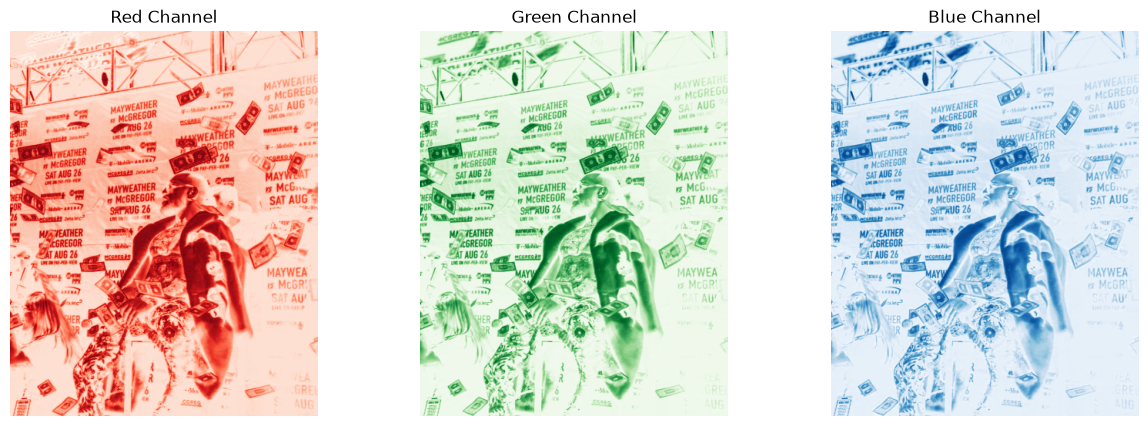

In [4]:
if content_tensor is not None:
    # Extract channels. Shape is [1, 3, H, W], so [0, 0, :, :] is Red, [0, 1, :, :] is Green, etc.
    red_channel = content_tensor[0, 0, :, :]
    green_channel = content_tensor[0, 1, :, :]
    blue_channel = content_tensor[0, 2, :, :]
    
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    # Using 'Reds', 'Greens', 'Blues' colormaps to show intensity
    ax[0].imshow(red_channel.numpy(), cmap='Reds')
    ax[0].set_title('Red Channel')
    ax[0].axis('off')
    
    ax[1].imshow(green_channel.numpy(), cmap='Greens')
    ax[1].set_title('Green Channel')
    ax[1].axis('off')
    
    ax[2].imshow(blue_channel.numpy(), cmap='Blues')
    ax[2].set_title('Blue Channel')
    ax[2].axis('off')
    
    plt.show()